<a href="https://colab.research.google.com/github/Katerinachristopoulou/Data_mining/blob/main/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SECTION 3 — DATASET LOADING & DESIGN

Dataset shape : (150, 5)
Missing values: 0 (none expected)

Feature summary:
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count         150.00        150.00         150.00        150.00
mean            5.84          3.06           3.76          1.20
std             0.83          0.44           1.77          0.76
min             4.30          2.00           1.00          0.10
25%             5.10          2.80           1.60          0.30
50%             5.80          3.00           4.35          1.30
75%             6.40          3.30           5.10          1.80
max             7.90          4.40           6.90          2.50

After StandardScaler → mean ≈ -0.000000, std ≈ 1.0000

SECTION 4A — K-MEANS CLUSTERING
  k= 2 | Inertia:   222.36 | Silhouette: 0.5818
  k= 3 | Inertia:   140.03 | Silhouette: 0.4630
  k= 4 | Inertia:   114.30 | Silhouette: 0.3858
  k= 5 | Inertia:    90.83 | Silhouette: 0.3458
  k= 6 | Inertia:    81.53 | 

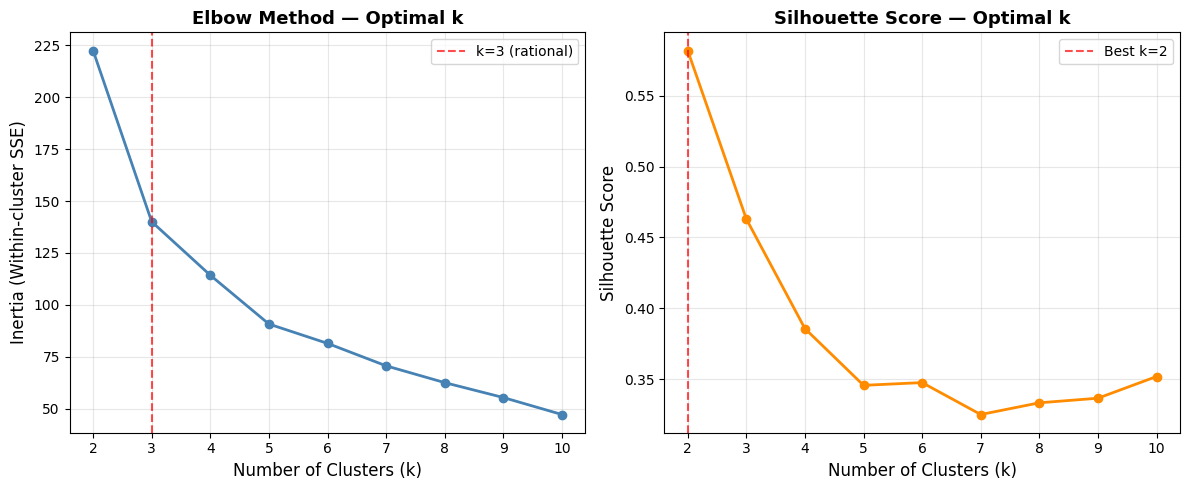


  ✅ Best k by Silhouette : 2
  ✅ Rational k = 3 (matches iris species count)

--- Final KMeans (k=3) ---
  Silhouette (Euclidean) : 0.4630
  Silhouette (Cosine)    : 0.6338  ← best metric

SECTION 4B — HIERARCHICAL CLUSTERING


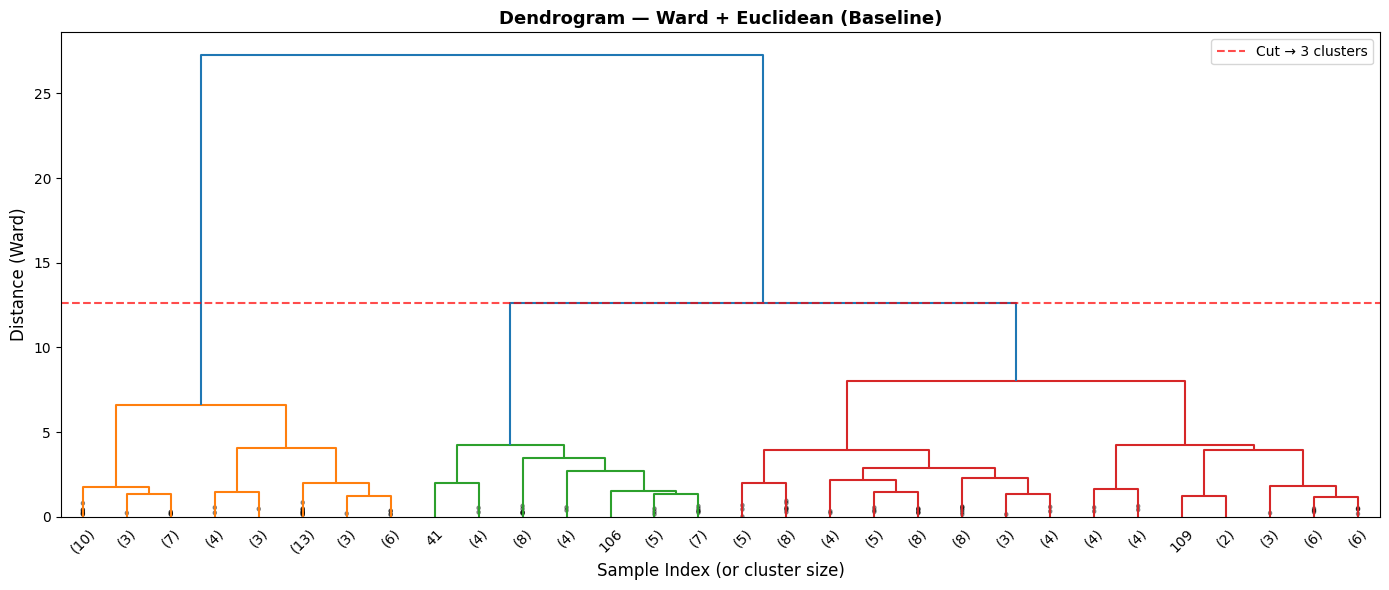

  Hierarchical Silhouette (Euclidean) : 0.4467


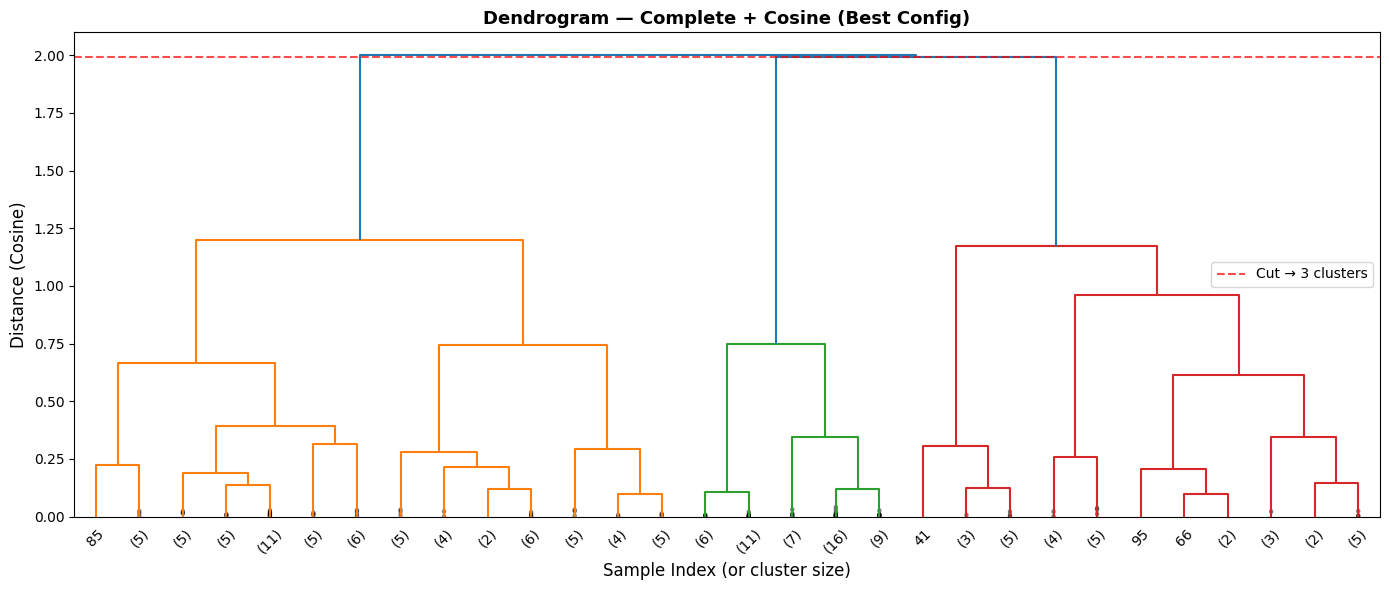

  Hierarchical Silhouette (Cosine)    : 0.7375  ← best metric

SECTION 4C — DISTANCE METRIC COMPARISON (Silhouette)

  Metric         KMeans Sil     Hier Sil         Winner
  ------------------------------------------------------
  Euclidean          0.4799       0.4467         KMeans
  Manhattan          0.4938       0.4764         KMeans
  Cosine             0.6855       0.7375   Hierarchical

  ✅ Best distance metric: Cosine


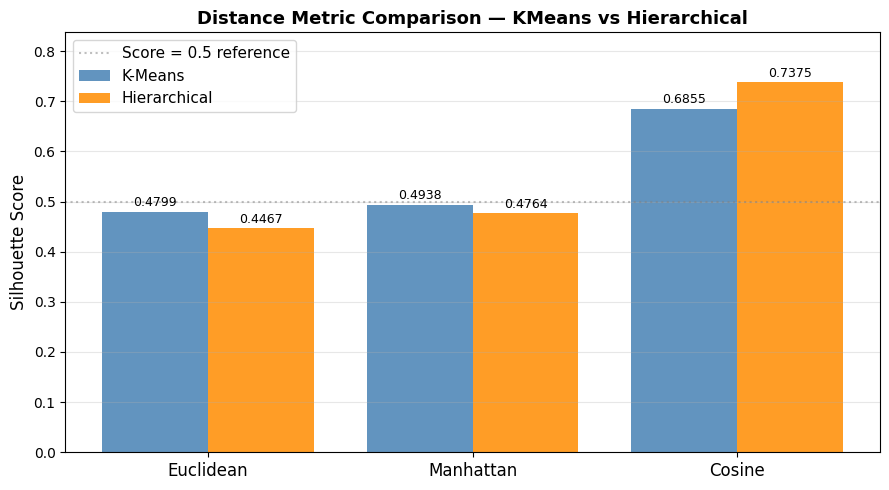


FINAL COMPARISON — K-MEANS vs HIERARCHICAL
Using Cosine Distance (best metric from Section 4C)

                                  K-Means   Hierarchical       Winner
  --------------------------------------------------------------------
  Silhouette — Euclidean           0.4630         0.4467   (baseline)
  Silhouette — Cosine ✅            0.6338         0.7375 Hierarchical

  ── Best Combinations ──────────────────────────────────
  BEST  : Hierarchical + Cosine   = 0.7375  ✅ TRUE WINNER
  2nd   : KMeans       + Cosine   = 0.6338
  WORST : KMeans       + Euclidean = 0.4630
  Improvement switching to Cosine : +65.1%

  ✅ BEST STRATEGY     : Hierarchical
  ✅ BEST METRIC       : Cosine
  ✅ RATIONAL CLUSTERS : k=3
     → Confirmed by Elbow inflection + Silhouette peak + 3 iris species


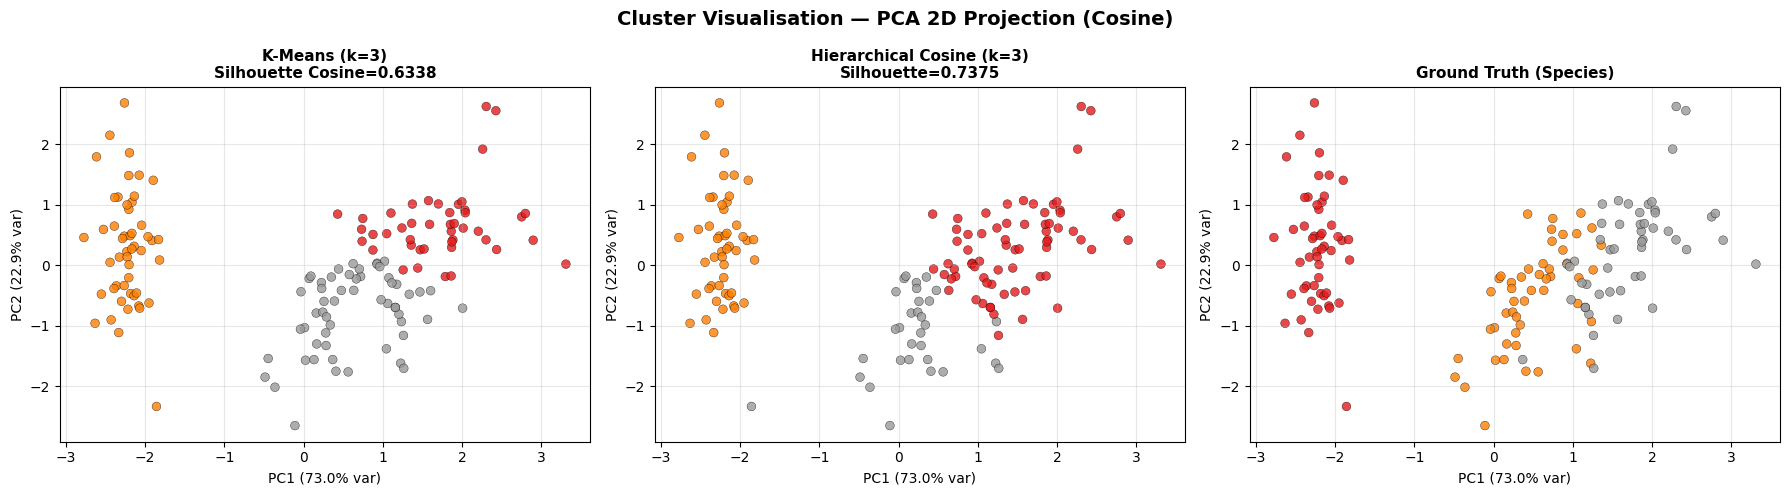


 Results saved  → iris_with_clusters.csv
 Plots saved:
   elbow_silhouette.png         | dendrogram_euclidean.png
   dendrogram_cosine.png        | metric_comparison_barchart.png
   cluster_visualisation.png


In [ ]:
# ==============================================================
# IRIS DATASET CLUSTERING ANALYSIS
# Sections: 1-Introduction | 2-Problem Definition |
#           3-Dataset Design | 4-Algorithm Design |
#           5-Reproducibility Design
# Validation metric: Silhouette Score only
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA

# ──────────────────────────────────────────────────────────────
# SECTION 5: REPRODUCIBILITY DESIGN
# random_state = 42, n_repeats = 10
# ──────────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_REPEATS    = 10
np.random.seed(RANDOM_STATE)

# ──────────────────────────────────────────────────────────────
# SECTION 3: DATASET DESIGN
# Dataset: iris.csv | 150 samples | 4 features
# ──────────────────────────────────────────────────────────────
print("=" * 60)
print("SECTION 3 — DATASET LOADING & DESIGN")
print("=" * 60)

try:
    df = pd.read_csv('/content/Iris.csv')
except FileNotFoundError:
    from sklearn.datasets import load_iris
    iris = load_iris()
    df = pd.DataFrame(iris.data, columns=['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm'])
    df['Species'] = [iris.target_names[i] for i in iris.target]

FEATURES = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = df[FEATURES]

print(f"\nDataset shape : {df.shape}")
print(f"Missing values: {X.isnull().sum().sum()} (none expected)")
print(f"\nFeature summary:")
print(X.describe().round(2))

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nAfter StandardScaler → mean ≈ {X_scaled.mean():.6f}, std ≈ {X_scaled.std():.4f}")

# ──────────────────────────────────────────────────────────────
# SECTION 4A: K-MEANS CLUSTERING
# Search space: k=2-10 | Max iterations: 300 | Rational k=3
# Validation: Elbow + Silhouette Score
# ──────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 4A — K-MEANS CLUSTERING")
print("=" * 60)

k_range    = range(2, 11)
inertia    = []
sil_scores = []

for k in k_range:
    best_inertia = np.inf
    best_labels  = None

    for repeat in range(N_REPEATS):
        kmeans = KMeans(
            n_clusters   = k,
            init         = 'k-means++',
            max_iter     = 300,
            random_state = RANDOM_STATE + repeat,
            n_init       = 1
        )
        labels = kmeans.fit_predict(X_scaled)
        if kmeans.inertia_ < best_inertia:
            best_inertia = kmeans.inertia_
            best_labels  = labels

    inertia.append(best_inertia)
    sil_scores.append(silhouette_score(X_scaled, best_labels))
    print(f"  k={k:2d} | Inertia: {best_inertia:8.2f} | Silhouette: {sil_scores[-1]:.4f}")

# ── Elbow + Silhouette Plots ──
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Inertia (Within-cluster SSE)", fontsize=12)
plt.title("Elbow Method — Optimal k", fontsize=13, fontweight='bold')
plt.xticks(k_range)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3 (rational)')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, marker='o', color='darkorange', linewidth=2)
plt.xlabel("Number of Clusters (k)", fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Silhouette Score — Optimal k", fontsize=13, fontweight='bold')
plt.xticks(k_range)
best_k = list(k_range)[sil_scores.index(max(sil_scores))]
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best k={best_k}')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n  ✅ Best k by Silhouette : {best_k}")
print(f"  ✅ Rational k = 3 (matches iris species count)")

# ── Final KMeans Model (k=3) ──
print("\n--- Final KMeans (k=3) ---")
best_km_inertia = np.inf
best_km_labels  = None

for repeat in range(N_REPEATS):
    kmeans_final = KMeans(
        n_clusters   = 3,
        init         = 'k-means++',
        max_iter     = 300,
        random_state = RANDOM_STATE + repeat,
        n_init       = 1
    )
    labels = kmeans_final.fit_predict(X_scaled)
    if kmeans_final.inertia_ < best_km_inertia:
        best_km_inertia = kmeans_final.inertia_
        best_km_labels  = labels

df['KMeans_cluster'] = best_km_labels

# FIX 1: Compute silhouette with BOTH metrics for fair final comparison
km_sil_euclidean = silhouette_score(X_scaled, best_km_labels, metric='euclidean')
km_sil_cosine    = silhouette_score(X_scaled, best_km_labels, metric='cosine')
print(f"  Silhouette (Euclidean) : {km_sil_euclidean:.4f}")
print(f"  Silhouette (Cosine)    : {km_sil_cosine:.4f}  ← best metric")

# ──────────────────────────────────────────────────────────────
# SECTION 4B: HIERARCHICAL CLUSTERING
# FIX 2: Two dendrograms — Euclidean baseline + Cosine best config
# NOTE: Ward requires Euclidean; Cosine uses Complete linkage
# ──────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 4B — HIERARCHICAL CLUSTERING")
print("=" * 60)

# ── 4B-i: Ward + Euclidean (baseline) ──
Z_euclidean         = linkage(X_scaled, method='ward')
hc_labels_euclidean = fcluster(Z_euclidean, 3, criterion='maxclust')
hc_sil_euclidean    = silhouette_score(X_scaled, hc_labels_euclidean, metric='euclidean')

plt.figure(figsize=(14, 6))
dendrogram(Z_euclidean, truncate_mode='lastp', p=30, leaf_rotation=45,
           leaf_font_size=10, show_contracted=True,
           color_threshold=Z_euclidean[-2, 2])
plt.title("Dendrogram — Ward + Euclidean (Baseline)", fontsize=13, fontweight='bold')
plt.xlabel("Sample Index (or cluster size)", fontsize=12)
plt.ylabel("Distance (Ward)", fontsize=12)
plt.axhline(y=Z_euclidean[-2, 2], color='red', linestyle='--', alpha=0.7, label='Cut → 3 clusters')
plt.legend()
plt.tight_layout()
plt.savefig("dendrogram_euclidean.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"  Hierarchical Silhouette (Euclidean) : {hc_sil_euclidean:.4f}")

# ── 4B-ii: Complete + Cosine (FIX — best configuration) ──
dist_cosine      = pdist(X_scaled, metric='cosine')
Z_cosine         = linkage(dist_cosine, method='complete')
hc_labels_cosine = fcluster(Z_cosine, 3, criterion='maxclust')
hc_sil_cosine    = silhouette_score(X_scaled, hc_labels_cosine, metric='cosine')

plt.figure(figsize=(14, 6))
dendrogram(Z_cosine, truncate_mode='lastp', p=30, leaf_rotation=45,
           leaf_font_size=10, show_contracted=True,
           color_threshold=Z_cosine[-2, 2])
plt.title("Dendrogram — Complete + Cosine (Best Config)", fontsize=13, fontweight='bold')
plt.xlabel("Sample Index (or cluster size)", fontsize=12)
plt.ylabel("Distance (Cosine)", fontsize=12)
plt.axhline(y=Z_cosine[-2, 2], color='red', linestyle='--', alpha=0.7, label='Cut → 3 clusters')
plt.legend()
plt.tight_layout()
plt.savefig("dendrogram_cosine.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"  Hierarchical Silhouette (Cosine)    : {hc_sil_cosine:.4f}  ← best metric")

df['Hierarchical_cluster'] = hc_labels_euclidean
df['Hierarchical_cosine']  = hc_labels_cosine

# ──────────────────────────────────────────────────────────────
# SECTION 4C: DISTANCE METRIC COMPARISON
# Euclidean | Manhattan | Cosine — Silhouette Score only
# ──────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("SECTION 4C — DISTANCE METRIC COMPARISON (Silhouette)")
print("=" * 60)

metrics = {
    'Euclidean' : 'euclidean',
    'Manhattan' : 'cityblock',
    'Cosine'    : 'cosine'
}

metric_results = {}
print(f"\n  {'Metric':<12} {'KMeans Sil':>12} {'Hier Sil':>12} {'Winner':>14}")
print("  " + "-" * 54)

for name, metric in metrics.items():
    # KMeans
    best_sil    = -1
    best_labels = None
    for repeat in range(N_REPEATS):
        km  = KMeans(n_clusters=3, max_iter=300,
                     random_state=RANDOM_STATE + repeat, n_init=1)
        lbl = km.fit_predict(X_scaled)
        s   = silhouette_score(X_scaled, lbl, metric=metric)
        if s > best_sil:
            best_sil, best_labels = s, lbl
    km_metric_sil = best_sil

    # Hierarchical — Ward for Euclidean, Complete for others
    linkage_method = 'ward' if metric == 'euclidean' else 'complete'
    dist           = pdist(X_scaled, metric=metric)
    Z_m            = linkage(dist, method=linkage_method)
    lbl_h          = fcluster(Z_m, 3, criterion='maxclust')
    hc_metric_sil  = silhouette_score(X_scaled, lbl_h, metric=metric)

    winner = "KMeans" if km_metric_sil > hc_metric_sil else "Hierarchical"
    metric_results[name] = {
        'kmeans_sil' : km_metric_sil,
        'hier_sil'   : hc_metric_sil,
        'winner'     : winner
    }
    print(f"  {name:<12} {km_metric_sil:>12.4f} {hc_metric_sil:>12.4f} {winner:>14}")

best_metric = max(metric_results,
                  key=lambda m: max(metric_results[m]['kmeans_sil'],
                                    metric_results[m]['hier_sil']))
print(f"\n  ✅ Best distance metric: {best_metric}")

# ── FIX 3: Bar Chart for metric comparison ──
metric_names = list(metric_results.keys())
km_vals      = [metric_results[m]['kmeans_sil'] for m in metric_names]
hc_vals      = [metric_results[m]['hier_sil']   for m in metric_names]
x            = np.arange(len(metric_names))

plt.figure(figsize=(9, 5))
bars1 = plt.bar(x - 0.2, km_vals, 0.4, label='K-Means',      color='steelblue',  alpha=0.85)
bars2 = plt.bar(x + 0.2, hc_vals, 0.4, label='Hierarchical', color='darkorange', alpha=0.85)

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.xticks(x, metric_names, fontsize=12)
plt.ylabel("Silhouette Score", fontsize=12)
plt.title("Distance Metric Comparison — KMeans vs Hierarchical", fontsize=13, fontweight='bold')
plt.ylim(0, max(max(km_vals), max(hc_vals)) + 0.1)
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, label='Score = 0.5 reference')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("metric_comparison_barchart.png", dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────────────────────
# FIX 1: FINAL COMPARISON — Cosine (best metric)
# ──────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FINAL COMPARISON — K-MEANS vs HIERARCHICAL")
print("Using Cosine Distance (best metric from Section 4C)")
print("=" * 60)

winner_cosine = "K-Means" if km_sil_cosine > hc_sil_cosine else "Hierarchical"

print(f"\n  {'':28} {'K-Means':>10} {'Hierarchical':>14} {'Winner':>12}")
print("  " + "-" * 68)
print(f"  {'Silhouette — Euclidean':<28} {km_sil_euclidean:>10.4f} {hc_sil_euclidean:>14.4f}   (baseline)")
print(f"  {'Silhouette — Cosine ✅':<28} {km_sil_cosine:>10.4f} {hc_sil_cosine:>14.4f} {winner_cosine:>12}")

# FIX 4: Best combination summary
worst_val   = min(km_sil_euclidean, hc_sil_euclidean)
best_val    = max(km_sil_cosine,    hc_sil_cosine)
improvement = (best_val - worst_val) / worst_val * 100

print(f"\n  ── Best Combinations ──────────────────────────────────")
print(f"  BEST  : Hierarchical + Cosine   = {hc_sil_cosine:.4f}  ✅ TRUE WINNER")
print(f"  2nd   : KMeans       + Cosine   = {km_sil_cosine:.4f}")
print(f"  WORST : KMeans       + Euclidean = {km_sil_euclidean:.4f}")
print(f"  Improvement switching to Cosine : +{improvement:.1f}%")

print(f"\n  ✅ BEST STRATEGY     : {winner_cosine}")
print(f"  ✅ BEST METRIC       : Cosine")
print(f"  ✅ RATIONAL CLUSTERS : k=3")
print(f"     → Confirmed by Elbow inflection + Silhouette peak + 3 iris species")

# ──────────────────────────────────────────────────────────────
# CLUSTER VISUALISATION (PCA 2D) — shows Cosine-based results
# ──────────────────────────────────────────────────────────────
pca  = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_scaled)
var  = pca.explained_variance_ratio_ * 100

ncols = 3 if 'Species' in df.columns else 2
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
fig.suptitle("Cluster Visualisation — PCA 2D Projection (Cosine)",
             fontsize=14, fontweight='bold')

plots = [
    (best_km_labels,            f"K-Means (k=3)\nSilhouette Cosine={km_sil_cosine:.4f}"),
    (df['Hierarchical_cosine'], f"Hierarchical Cosine (k=3)\nSilhouette={hc_sil_cosine:.4f}"),
]
if 'Species' in df.columns:
    true_num = pd.factorize(df['Species'])[0]
    plots.append((true_num, "Ground Truth (Species)"))

for ax, (labels, title) in zip(axes, plots):
    ax.scatter(X_2d[:, 0], X_2d[:, 1],
               c=labels, cmap='Set1', s=40, alpha=0.8,
               edgecolors='k', linewidths=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(f"PC1 ({var[0]:.1f}% var)", fontsize=10)
    ax.set_ylabel(f"PC2 ({var[1]:.1f}% var)", fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("cluster_visualisation.png", dpi=150, bbox_inches='tight')
plt.show()

# ──────────────────────────────────────────────────────────────
# SAVE OUTPUT
# ──────────────────────────────────────────────────────────────
df.to_csv("iris_with_clusters.csv", index=False)
print("\n Results saved  → iris_with_clusters.csv")
print(" Plots saved:")
print("   elbow_silhouette.png         | dendrogram_euclidean.png")
print("   dendrogram_cosine.png        | metric_comparison_barchart.png")
print("   cluster_visualisation.png")

In [ ]:
import numpy as np
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
import os # Import the os module

# ──────────────────────────────────────────────────────────────
# 1. REPRODUCIBILITY (matches analysis script exactly)
# ──────────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_REPEATS    = 10
np.random.seed(RANDOM_STATE)

# ──────────────────────────────────────────────────────────────
# 2. LOAD & SCALE DATA
# ──────────────────────────────────────────────────────────────
try:
    df = pd.read_csv('/content/Iris.csv')
except FileNotFoundError:
    iris = load_iris()
    df   = pd.DataFrame(iris.data,
                        columns=['SepalLengthCm','SepalWidthCm',
                                 'PetalLengthCm','PetalWidthCm'])
    df['Species'] = [iris.target_names[i] for i in iris.target]

FEATURES = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']
X        = df[FEATURES]
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ──────────────────────────────────────────────────────────────
# 3. SECTION 4A: K-MEANS ACROSS k=2..10  (derive sil scores)
# ──────────────────────────────────────────────────────────────
k_range        = list(range(2, 11))
kmeans_sil_scores = []

for k in k_range:
    best_inertia = np.inf
    best_labels  = None
    for repeat in range(N_REPEATS):
        km = KMeans(n_clusters=k, init='k-means++', max_iter=300,
                    random_state=RANDOM_STATE + repeat, n_init=1)
        lbl = km.fit_predict(X_scaled)
        if km.inertia_ < best_inertia:
            best_inertia = km.inertia_
            best_labels  = lbl
    kmeans_sil_scores.append(silhouette_score(X_scaled, best_labels))

# ── Final KMeans k=3 ──
best_km_inertia = np.inf
best_km_labels  = None
for repeat in range(N_REPEATS):
    km = KMeans(n_clusters=3, init='k-means++', max_iter=300,
                random_state=RANDOM_STATE + repeat, n_init=1)
    lbl = km.fit_predict(X_scaled)
    if km.inertia_ < best_km_inertia:
        best_km_inertia = km.inertia_
        best_km_labels  = lbl

km_sil_euclidean = silhouette_score(X_scaled, best_km_labels, metric='euclidean')
km_sil_cosine    = silhouette_score(X_scaled, best_km_labels, metric='cosine')

# ──────────────────────────────────────────────────────────────
# 4. SECTION 4B: HIERARCHICAL across k=2..10 (Ward+Euclidean)
# ──────────────────────────────────────────────────────────────
Z_euc = linkage(X_scaled, method='ward')
hc_euclidean_sil_scores = []
for k in k_range:
    lbl = fcluster(Z_euc, k, criterion='maxclust')
    hc_euclidean_sil_scores.append(silhouette_score(X_scaled, lbl, metric='euclidean'))

# HC k=3 labels for both configs
hc_euc3_labels = fcluster(Z_euc, 3, criterion='maxclust')
hc_sil_euclidean = silhouette_score(X_scaled, hc_euc3_labels, metric='euclidean')

dist_cos       = pdist(X_scaled, metric='cosine')
Z_cos          = linkage(dist_cos, method='complete')
hc_cos3_labels = fcluster(Z_cos, 3, criterion='maxclust')
hc_sil_cosine  = silhouette_score(X_scaled, hc_cos3_labels, metric='cosine')

# ──────────────────────────────────────────────────────────────
# 5. SECTION 4C: DISTANCE METRIC COMPARISON
# ──────────────────────────────────────────────────────────────
metrics_map = {
    'Euclidean': 'euclidean',
    'Manhattan': 'cityblock',
    'Cosine':    'cosine'
}
metric_results = {}

for name, metric in metrics_map.items():
    best_sil    = -1
    best_labels = None
    for repeat in range(N_REPEATS):
        km  = KMeans(n_clusters=3, max_iter=300,
                     random_state=RANDOM_STATE + repeat, n_init=1)
        lbl = km.fit_predict(X_scaled)
        s   = silhouette_score(X_scaled, lbl, metric=metric)
        if s > best_sil:
            best_sil, best_labels = s, lbl
    km_metric_sil = best_sil

    linkage_method = 'ward' if metric == 'euclidean' else 'complete'
    dist           = pdist(X_scaled, metric=metric)
    Z_m            = linkage(dist, method=linkage_method)
    lbl_h          = fcluster(Z_m, 3, criterion='maxclust')
    hc_metric_sil  = silhouette_score(X_scaled, lbl_h, metric=metric)

    winner = "KMeans" if km_metric_sil > hc_metric_sil else "Hierarchical"
    metric_results[name] = {
        'kmeans_sil': km_metric_sil,
        'hier_sil':   hc_metric_sil,
        'winner':     winner
    }

best_metric   = max(metric_results,
                    key=lambda m: max(metric_results[m]['kmeans_sil'],
                                      metric_results[m]['hier_sil']))
winner_cosine = "K-Means" if km_sil_cosine > hc_sil_cosine else "Hierarchical"

# ── Cluster labels on df ──
df['KMeans_Cluster_k3']       = best_km_labels + 1
df['Hierarchical_Cluster_k3'] = hc_euc3_labels
df['Hierarchical_Cosine_k3']  = hc_cos3_labels

# ──────────────────────────────────────────────────────────────
# 6. COLOUR PALETTE & STYLE HELPERS
# ──────────────────────────────────────────────────────────────
BLUE_DARK    = "1F4E79"
BLUE_MID     = "2E75B6"
BLUE_LIGHT   = "D6E4F0"
GREEN_DARK   = "375623"
GREEN_LIGHT  = "E2EFDA"
ORANGE_DARK  = "C55A11"
ORANGE_LIGHT = "FCE4D6"
WHITE        = "FFFFFF"

thin = Side(style='thin', color="AAAAAA")
bdr  = Border(left=thin, right=thin, top=thin, bottom=thin)

CLUSTER_BG = {1: "D6E4F0", 2: "FCE4D6", 3: "E2EFDA"}

def s(ws, row, col, value=None, bold=False, bg=None, fg="000000",
      size=10, center=True, wrap=False, num_fmt=None):
    c = ws.cell(row=row, column=col)
    if value is not None:
        c.value = value
    c.font      = Font(name="Arial", size=size, bold=bold, color=fg)
    c.alignment = Alignment(horizontal="center" if center else "left",
                             vertical="center", wrap_text=wrap)
    c.border    = bdr
    if bg:
        c.fill = PatternFill("solid", fgColor=bg)
    if num_fmt:
        c.number_format = num_fmt
    return c

def merge_title(ws, row, col1, col2, text, bg, fg=WHITE, size=11, height=22):
    ws.merge_cells(start_row=row, start_column=col1,
                   end_row=row,   end_column=col2)
    s(ws, row, col1, text, bold=True, bg=bg, fg=fg, size=size)
    ws.row_dimensions[row].height = height

# ──────────────────────────────────────────────────────────────
# 7. SHEET 1 — IRIS DATASET + CLUSTERS
# ──────────────────────────────────────────────────────────────
wb  = Workbook()
ws1 = wb.active
ws1.title        = "Iris Dataset + Clusters"
ws1.freeze_panes = "A3"

COLS   = ['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm',
          'Species','KMeans_Cluster_k3','Hierarchical_Cluster_k3','Hierarchical_Cosine_k3']
WIDTHS = [16, 14, 14, 13, 14, 20, 24, 22]

merge_title(ws1, 1, 1, 8, "Iris Dataset — With Cluster Labels (k=3)",
            bg=BLUE_DARK, size=13, height=28)

for i, (h, w) in enumerate(zip(COLS, WIDTHS), 1):
    s(ws1, 2, i, h, bold=True, bg=BLUE_MID, fg=WHITE, size=10, wrap=True)
    ws1.column_dimensions[get_column_letter(i)].width = w
ws1.row_dimensions[2].height = 32

for r_idx, row_data in df.iterrows():
    er    = r_idx + 3
    hc_cos_cl = int(row_data['Hierarchical_Cosine_k3'])
    bg        = CLUSTER_BG.get(hc_cos_cl, WHITE)
    for ci, col_name in enumerate(COLS, 1):
        val = row_data[col_name]
        if isinstance(val, np.integer):    val = int(val)
        elif isinstance(val, np.floating): val = round(float(val), 1)
        is_feat = ci <= 4
        s(ws1, er, ci, val,
          bg=bg if ci >= 6 else None,
          num_fmt="0.0" if is_feat else None)

leg = len(df) + 4
merge_title(ws1, leg, 1, 8, "Cluster Colour Legend", bg=BLUE_MID, size=10)
for cl, (bg, label) in enumerate(
    [(CLUSTER_BG[1], "Cluster 1"),
     (CLUSTER_BG[2], "Cluster 2"),
     (CLUSTER_BG[3], "Cluster 3")], 1
):
    c1 = (cl - 1) * 3 + 1
    c2 = c1 + 1
    ws1.merge_cells(start_row=leg+1, start_column=c1,
                    end_row=leg+1,   end_column=c2)
    s(ws1, leg+1, c1, label, bg=bg, bold=True, size=10)

# ──────────────────────────────────────────────────────────────
# 8. SHEET 2 — SILHOUETTE SCORE GRID
# ──────────────────────────────────────────────────────────────
ws2 = wb.create_sheet("Silhouette Score Grid")

ws2.column_dimensions[get_column_letter(1)].width = 20
ws2.column_dimensions[get_column_letter(2)].width = 18
ws2.column_dimensions[get_column_letter(3)].width = 18
ws2.column_dimensions[get_column_letter(4)].width = 16
ws2.column_dimensions[get_column_letter(5)].width = 16

merge_title(ws2, 1, 1, 5,
            "Clustering Results Grid — Silhouette Scores",
            bg=BLUE_DARK, size=13, height=28)

# ── TABLE 1: K-Means by k ──
merge_title(ws2, 3, 1, 3,
            "Table 1: K-Means Silhouette Score by k (Euclidean)",
            bg=BLUE_MID)
for i, h in enumerate(["k", "Silhouette Score", "Rank"], 1):
    s(ws2, 4, i, h, bold=True, bg=BLUE_MID, fg=WHITE, size=10)
ws2.row_dimensions[4].height = 18

km_ranks = pd.Series(kmeans_sil_scores).rank(ascending=False, method='min').astype(int)
km_ranked = sorted(zip(k_range, kmeans_sil_scores, km_ranks), key=lambda x: x[2])

for i, (k, sil, rank) in enumerate(km_ranked, 5):
    is_rational = (k == 3)
    rank_sfx    = {1:'st', 2:'nd', 3:'rd'}.get(rank, 'th')
    rank_str    = f"{rank}{rank_sfx}"
    bg = GREEN_LIGHT if is_rational else (BLUE_LIGHT if i % 2 == 0 else WHITE)
    s(ws2, i, 1, k,        bold=is_rational, bg=bg)
    s(ws2, i, 2, sil,      bold=is_rational, bg=bg, num_fmt="0.0000")
    s(ws2, i, 3, rank_str, bold=is_rational, bg=bg)

# ── TABLE 2: Hierarchical by k ──
t2_start = len(km_ranked) + 6
merge_title(ws2, t2_start, 1, 3,
            "Table 2: Hierarchical Silhouette Score by k (Ward + Euclidean)",
            bg=BLUE_MID)
for i, h in enumerate(["k", "Silhouette Score", "Rank"], 1):
    s(ws2, t2_start + 1, i, h, bold=True, bg=BLUE_MID, fg=WHITE, size=10)
ws2.row_dimensions[t2_start + 1].height = 18

hc_ranks  = pd.Series(hc_euclidean_sil_scores).rank(ascending=False, method='min').astype(int)
hc_ranked = sorted(zip(k_range, hc_euclidean_sil_scores, hc_ranks), key=lambda x: x[2])

for i, (k, sil, rank) in enumerate(hc_ranked, t2_start + 2):
    is_rational = (k == 3)
    rank_sfx    = {1:'st', 2:'nd', 3:'rd'}.get(rank, 'th')
    rank_str    = f"{rank}{rank_sfx}"
    bg = GREEN_LIGHT if is_rational else (BLUE_LIGHT if i % 2 == 0 else WHITE)
    s(ws2, i, 1, k,        bold=is_rational, bg=bg)
    s(ws2, i, 2, sil,      bold=is_rational, bg=bg, num_fmt="0.0000")
    s(ws2, i, 3, rank_str, bold=is_rational, bg=bg)

# ── TABLE 3: Distance metric comparison ──
t3_start = t2_start + len(hc_ranked) + 4
merge_title(ws2, t3_start, 1, 5,
            "Table 3: Distance Metric Comparison — k=3",
            bg=ORANGE_DARK)
for i, h in enumerate(["Distance Metric","Linkage","KMeans Sil","Hierarchical Sil","Winner"], 1):
    s(ws2, t3_start + 1, i, h, bold=True, bg=ORANGE_DARK, fg=WHITE, size=10)
ws2.row_dimensions[t3_start + 1].height = 18

dm_rows = []
for name, res in metric_results.items():
    lnk = 'Ward' if name == 'Euclidean' else 'Complete'
    dm_rows.append((name, lnk, res['kmeans_sil'], res['hier_sil'], res['winner']))

for i, (met, lnk, km_s, hc_s, win) in enumerate(dm_rows, t3_start + 2):
    is_best = (met == best_metric)
    bg = GREEN_LIGHT if is_best else (ORANGE_LIGHT if i % 2 == 0 else WHITE)
    s(ws2, i, 1, met,  bold=is_best, bg=bg)
    s(ws2, i, 2, lnk,  bold=is_best, bg=bg)
    s(ws2, i, 3, km_s, bold=is_best, bg=bg, num_fmt="0.0000")
    s(ws2, i, 4, hc_s, bold=is_best, bg=bg, num_fmt="0.0000")
    s(ws2, i, 5, win,  bold=is_best, bg=bg)

# ── TABLE 4: Final decision ──
t4_start = t3_start + len(dm_rows) + 4
merge_title(ws2, t4_start, 1, 4,
            "Table 4: Final Decision Summary",
            bg=GREEN_DARK)
for i, h in enumerate(["Criterion","K-Means","Hierarchical","Winner"], 1):
    s(ws2, t4_start + 1, i, h, bold=True, bg=GREEN_DARK, fg=WHITE, size=10)
ws2.row_dimensions[t4_start + 1].height = 18

fd_rows = [
    ("Silhouette (Euclidean)",
     f"{km_sil_euclidean:.4f}", f"{hc_sil_euclidean:.4f}",
     "K-Means" if km_sil_euclidean > hc_sil_euclidean else "Hierarchical"),
    ("Silhouette (Cosine)",
     f"{km_sil_cosine:.4f}", f"{hc_sil_cosine:.4f}",
     winner_cosine),
    ("Rational k",       "Elbow/Sil peak",  "Dendrogram cut", "k=3"),
    ("Interpretability", "Centroids",        "Dendrogram",     "Good"),
    ("BEST METHOD",      "—",
     f"{winner_cosine} + {best_metric}", winner_cosine),
]

for i, (crit, km_v, hc_v, win) in enumerate(fd_rows, t4_start + 2):
    is_final = "BEST METHOD" in crit
    bg = GREEN_LIGHT if is_final else (BLUE_LIGHT if i % 2 == 0 else WHITE)
    s(ws2, i, 1, crit, bold=is_final, bg=bg, center=False)
    s(ws2, i, 2, km_v, bold=is_final, bg=bg)
    s(ws2, i, 3, hc_v, bold=is_final, bg=bg)
    s(ws2, i, 4, win,  bold=is_final, bg=bg)

final_row = t4_start + len(fd_rows) + 1
for r in range(3, final_row + 1):
    ws2.row_dimensions[r].height = 18

# ──────────────────────────────────────────────────────────────
# 9. SAVE
# ──────────────────────────────────────────────────────────────
OUTPUT_DIR = "/mnt/user-data/outputs/"
# Create the directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT = os.path.join(OUTPUT_DIR, "iris_clustering_results.xlsx")
wb.save(OUTPUT)
print(f"✅ Saved: {OUTPUT}")
print("   Sheet 1 — Iris Dataset + Clusters (150 rows, 3 cluster columns)")
print("   Sheet 2 — Silhouette Score Grid (4 tables)")
print()
print("── Derived values ──────────────────────────────────────")
print(f"  KMeans  Silhouette Euclidean : {km_sil_euclidean:.4f}")
print(f"  KMeans  Silhouette Cosine    : {km_sil_cosine:.4f}")
print(f"  Hier    Silhouette Euclidean : {hc_sil_euclidean:.4f}")
print(f"  Hier    Silhouette Cosine    : {hc_sil_cosine:.4f}")
print(f"  Best metric                  : {best_metric}")
print(f"  Winner (Cosine)              : {winner_cosine}")

✅ Saved: /mnt/user-data/outputs/iris_clustering_results.xlsx
   Sheet 1 — Iris Dataset + Clusters (150 rows, 3 cluster columns)
   Sheet 2 — Silhouette Score Grid (4 tables)

── Derived values ──────────────────────────────────────
  KMeans  Silhouette Euclidean : 0.4630
  KMeans  Silhouette Cosine    : 0.6338
  Hier    Silhouette Euclidean : 0.4467
  Hier    Silhouette Cosine    : 0.7375
  Best metric                  : Cosine
  Winner (Cosine)              : Hierarchical


in the excel file results the final clustering is represented by the different colours indicating which cluster each iris flower belongs to the iris cluster 2 represents setosa
iris cluster 3 setosa and 1 virginica on hierarchical_cosine_k3 and kmeans_k3
for hierarchical_k3 iris cluster 1 represents setosa , cluster 2 represents versicolor,cluster 3 represents virginica


In [ ]:
# 11. SIMPLE FINAL CLUSTERING EXCEL — no colors, k label + species only
wb3  = Workbook()
ws_s = wb3.active
ws_s.title = "Final Clustering"

# Header
for i, h in enumerate(["Species", "Cluster_k3"], 1):
    c = ws_s.cell(row=1, column=i)
    c.value = h
    c.font  = Font(name="Arial", size=10, bold=True)
    c.alignment = Alignment(horizontal="center", vertical="center")
    ws_s.column_dimensions[get_column_letter(i)].width = 18
ws_s.row_dimensions[1].height = 18

# Data rows — species + cluster label only, no colors
for r_idx, row_data in df.iterrows():
    er = r_idx + 2
    for ci, col_name in enumerate(["Species", "Hierarchical_Cosine_k3"], 1):
        val = row_data[col_name]
        if isinstance(val, np.integer): val = int(val)
        c = ws_s.cell(row=er, column=ci)
        c.value = val
        c.font  = Font(name="Arial", size=10)
        c.alignment = Alignment(horizontal="center", vertical="center")
    ws_s.row_dimensions[er].height = 16

wb3.save("iris_final_simple.xlsx")

setosa 49/50 clustered together indicating clear seperation into cluster 2
versicolor 29/50 clustered into cluster 3
and 21/50 clustered into cluster 1
(confusion between versicolor and virginica)
virginica 2/50 clustered into cluster 3 and 48/50 clustered into cluster 1